# Including Conditional Variables

The hypernetwork $f_\phi$ maps a stochastic latent code $z \sim p(z)$ to a set of weights $\theta = f_\phi(z)$, which parameterize a base model. By default, the only source of variation in the generated weights is the random draw of $z$.

**Conditional variables** extend this by concatenating an observed condition vector $C$ to the latent code before passing it through $f_\phi$:

$$\theta = f_\phi([z, C])$$

This allows a single hypernetwork to produce *different families of weight distributions* depending on $C$. Useful applications include:

- **Multi-task learning** — one hypernetwork serves several related tasks, selected by $C$.
- **Domain adaptation** — $C$ encodes the source domain.
- **Conditional generation** — steer the predictive distribution with side information.

In this notebook we demonstrate the idea with a simple synthetic example: **5 discrete 2D Gaussian distributions**, where a one-hot encoding of the distribution label serves as $C$.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from hnet.models.MLP import MLP
from hnet.models.HyperNet import HyperNet
from hnet.train.hnet import EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}')

Using cuda


## 1. Synthetic Data

We create 5 two-dimensional Gaussian distributions, each with a distinct mean and covariance. For every sampled point we store a **one-hot label** indicating which distribution it came from — this will be the conditional variable $C$.

In [2]:
torch.manual_seed(42)

N_DISTRIBUTIONS = 5
N_POINTS = 200

means = [
    torch.tensor([-4.0, -4.0]),
    torch.tensor([ 4.0, -4.0]),
    torch.tensor([ 0.0,  5.0]),
    torch.tensor([-5.0,  3.0]),
    torch.tensor([ 5.0,  3.0]),
]

covariances = [
    torch.tensor([[1.0, 0.0],  [0.0, 1.0]]),
    torch.tensor([[0.4, 0.3],  [0.3, 0.4]]),
    torch.tensor([[1.5, -0.7], [-0.7, 0.6]]),
    torch.tensor([[0.3, 0.0],  [0.0, 1.8]]),
    torch.tensor([[1.2, 0.9],  [0.9, 1.2]]),
]

all_points, all_labels = [], []
for k in range(N_DISTRIBUTIONS):
    dist = torch.distributions.MultivariateNormal(means[k], covariances[k])
    pts = dist.sample((N_POINTS,))
    all_points.append(pts)
    all_labels.append(torch.full((N_POINTS,), k, dtype=torch.long))

Y = torch.cat(all_points, dim=0)           # (1000, 2)
labels = torch.cat(all_labels, dim=0)       # (1000,)
C_all = torch.nn.functional.one_hot(labels, num_classes=N_DISTRIBUTIONS).float()

print(f'Y shape:      {Y.shape}')
print(f'Labels shape:  {labels.shape}')
print(f'C shape:       {C_all.shape}')

Y shape:      torch.Size([1000, 2])
Labels shape:  torch.Size([1000])
C shape:       torch.Size([1000, 5])


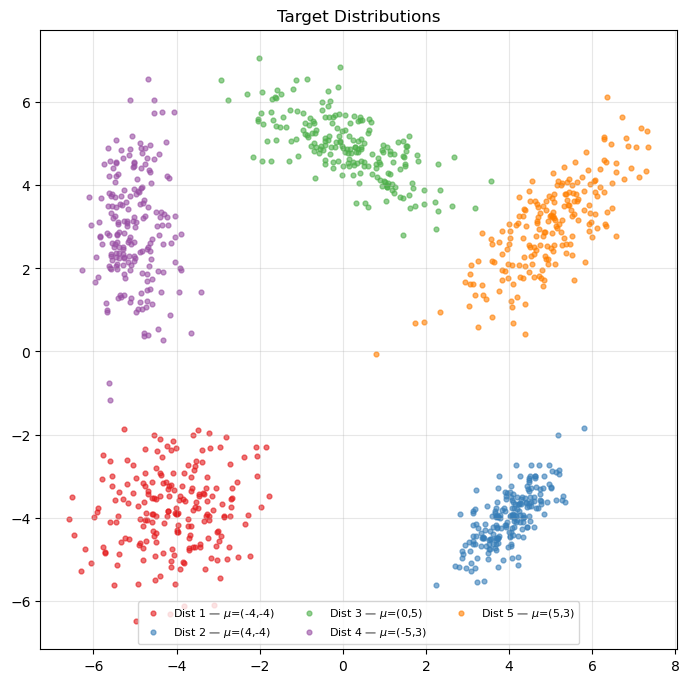

In [3]:
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(7, 7))
for k in range(N_DISTRIBUTIONS):
    pts = all_points[k]
    ax.scatter(pts[:, 0], pts[:, 1], c=COLORS[k], s=12, alpha=0.6,
              label=f'Dist {k+1} — $\\mu$=({means[k][0]:.0f},{means[k][1]:.0f})')
ax.set_title('Target Distributions')
ax.legend(loc='lower center', ncol=3, fontsize=8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Model Setup

The **base model** is a tiny MLP that maps a 1-D dummy input to 2-D output. All the expressive power comes from the weights that the hypernetwork generates.

The **hypernetwork** is configured with `cond_dim=5` so that the $\phi$-network's input layer has size `stochastic_channels + 5`. At each forward pass:

1. Sample $z \sim p(z)$
2. Concatenate the one-hot condition: $[z, C]$
3. Produce weights: $\theta = f_\phi([z, C])$
4. Evaluate the base model: $\hat{y} = f_\theta(x)$

Because different values of $C$ shift the input to $f_\phi$, the hypernetwork can learn to generate an entirely different weight distribution for each condition.

In [4]:
base_model = MLP(in_channels=1, out_channels=2,
                 hidden_channels=64, layers=2, nonlin='elu')

model = HyperNet(base_model,
                 stochastic_channels=8,
                 width=128,
                 cond_dim=N_DISTRIBUTIONS,
                 nonlin='elu',
                 pz='normal').to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Total hypernetwork parameters: {n_params:,}')

Total hypernetwork parameters: 1,124,610


## 3. Training

We train with the **Energy Distance Loss**. For each distribution $k$:

1. Construct the one-hot $C_k$.
2. Feed a batch of target points $y$ from distribution $k$ together with a dummy input $x=0$.
3. The hypernetwork produces an ensemble of predictions $\{\hat{y}_s\}_{s=1}^{S}$ conditioned on $C_k$.
4. The energy distance encourages the *ensemble* of predictions at each batch element to match the corresponding target distribution.

Because $C$ differs across the 5 distributions, the hypernetwork learns to map each one-hot condition to a different family of weights.

In [ ]:
crit = EnergyDistanceLoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-4)

N_EPOCHS = 2000
N_SAMPLES = 50
BATCH_SIZE = 64

losses = []
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    n_batches = 0

    for k in range(N_DISTRIBUTIONS):
        mask = labels == k
        y_k = Y[mask].to(device)

        C_k = torch.zeros(N_DISTRIBUTIONS, device=device)
        C_k[k] = 1.0

        for idx in torch.split(torch.randperm(y_k.size(0), device=device), BATCH_SIZE):
            optim.zero_grad()

            x_dummy = torch.zeros(len(idx), 1, device=device)
            yhat = model(x_dummy, samples=N_SAMPLES, C=C_k)

            loss = crit(yhat, y_k[idx])
            loss.backward()
            optim.step()

            epoch_loss += loss.item()
            n_batches += 1

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:>4d}/{N_EPOCHS} — loss: {avg_loss:.4f}')

print('Done.')

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(losses, lw=0.8)
plt.xlabel('Epoch')
plt.ylabel('Energy Distance Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Evaluation

For each condition $C_k$ we draw 500 weight samples from the hypernetwork and run the base model to produce 500 predicted 2-D points. We then overlay these on the true target distribution to see how well the hypernetwork has learned each Gaussian.

In [ ]:
model.eval()

fig, axes = plt.subplots(2, N_DISTRIBUTIONS, figsize=(4 * N_DISTRIBUTIONS, 8),
                         sharex=True, sharey=True)

with torch.no_grad():
    for k in range(N_DISTRIBUTIONS):
        C_k = torch.zeros(N_DISTRIBUTIONS, device=device)
        C_k[k] = 1.0

        x_dummy = torch.zeros(1, 1, device=device)
        preds = model(x_dummy, samples=500, C=C_k)[:, 0, :].cpu()

        ax_top = axes[0, k]
        pts = all_points[k]
        ax_top.scatter(pts[:, 0], pts[:, 1], c=COLORS[k], s=8, alpha=0.5)
        ax_top.set_title(f'Target {k+1}', fontsize=10)
        ax_top.set_aspect('equal')
        ax_top.grid(True, alpha=0.2)

        ax_bot = axes[1, k]
        ax_bot.scatter(preds[:, 0], preds[:, 1], c=COLORS[k], s=8, alpha=0.5)
        ax_bot.set_title(f'Predicted {k+1}', fontsize=10)
        ax_bot.set_aspect('equal')
        ax_bot.grid(True, alpha=0.2)

axes[0, 0].set_ylabel('Target', fontsize=12)
axes[1, 0].set_ylabel('HyperNet', fontsize=12)

plt.suptitle('Conditional Hypernetwork — Target vs. Predicted', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Combined Overlay

A single plot overlaying all 5 predicted distributions (crosses) on the true data (circles) makes the conditional steering especially visible.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

with torch.no_grad():
    for k in range(N_DISTRIBUTIONS):
        pts = all_points[k]
        ax.scatter(pts[:, 0], pts[:, 1], c=COLORS[k], s=12, alpha=0.4,
                  label=f'Target {k+1}')

        C_k = torch.zeros(N_DISTRIBUTIONS, device=device)
        C_k[k] = 1.0
        x_dummy = torch.zeros(1, 1, device=device)
        preds = model(x_dummy, samples=300, C=C_k)[:, 0, :].cpu()
        ax.scatter(preds[:, 0], preds[:, 1], c=COLORS[k], s=18, alpha=0.6,
                  marker='x', linewidths=0.8, label=f'Predicted {k+1}')

ax.set_title('All Distributions — Target (dots) vs. Predicted (crosses)')
ax.legend(loc='lower center', ncol=5, fontsize=7, columnspacing=0.8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

- The `cond_dim` parameter in `HyperNet` controls how many conditional dimensions are appended to the latent code $z$ before entering $f_\phi$.
- By passing a one-hot (or any other) condition vector $C$ at forward time, the **same** hypernetwork can produce distinct weight distributions — one per condition.
- Training with the **Energy Distance Loss** ensures that the ensemble of predictions for each condition matches the corresponding target distribution in a non-parametric sense.
- This mechanism generalises naturally: $C$ can encode task IDs, domain labels, class information, or any other discrete/continuous side information.